# SNR-Verteilung der Pulskandidaten

Rekonstruktion des SNR-Verteilungsplots aus den Metadata-Dateien fuer Train, Validation und Test.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Notebook liegt in WP2-1/DM_time_dataset_creator. Der Fallback erlaubt
# Ausfuehrung aus dem Repository-Root.
ROOT = Path.cwd()
if ROOT.name != "DM_time_dataset_creator":
    ROOT = Path("WP2-1/DM_time_dataset_creator")

OUTPUT_DIR = ROOT / "outputs"
PDF_PATH = ROOT / "data_snr_distribution.pdf"
DATASET_STEM = "B0531+21_59000_48386_DM_time_dataset_realbased"
SPLITS = ("train", "val", "test")

metadata_paths = [OUTPUT_DIR / f"{DATASET_STEM}_metadata_{split}.npy" for split in SPLITS]
for path in metadata_paths:
    if not path.exists():
        raise FileNotFoundError(path)

metadata = np.concatenate([np.load(path) for path in metadata_paths], axis=0)
snr_values = metadata[:, 0]
finite_snr = snr_values[np.isfinite(snr_values)]

# Der Referenzplot verwendet gerundete SNR-Werte als diskrete x-Positionen.
rounded_snr = np.rint(finite_snr).astype(int)
snr_levels, counts = np.unique(rounded_snr, return_counts=True)
percentages = counts / counts.sum() * 100

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 8,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
})

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.linewidth": 1.0,
    "lines.markersize": 3.5,
})

print(f"Metadata rows total: {metadata.shape[0]:,}")
print(f"Kandidaten mit endlicher SNR: {finite_snr.size:,}")
print(f"SNR range: {finite_snr.min():.1f} - {finite_snr.max():.1f}")

Metadata rows total: 1,722,368
Kandidaten mit endlicher SNR: 861,184
SNR range: 3.4 - 72.1


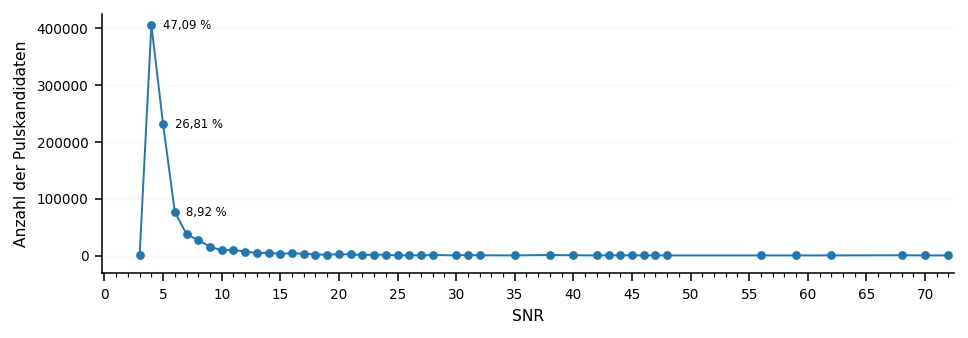

In [2]:
fig, ax = plt.subplots(figsize=(6.8, 2.3), constrained_layout=True)

ax.plot(
    snr_levels,
    counts,
    color="#1f77b4",
    marker="o",
    linewidth=1.0,
    markersize=3.5,
)

ax.set_xlabel("SNR")
ax.set_ylabel("Anzahl der Pulskandidaten")
ax.set_xlim(-0.2, 72.5)
ax.set_ylim(-30000, 425000)
ax.set_xticks(np.arange(0, 75, 5))
ax.set_xticks(np.arange(0, 73, 1), minor=True)
ax.tick_params(axis="x", which="major", length=4, width=0.8)
ax.tick_params(axis="x", which="minor", length=2, width=0.6)
ax.grid(axis="y", color="0.90", linewidth=0.7, linestyle="-")
ax.grid(axis="x", visible=False)
sns.despine(ax=ax)

percentage_by_level = dict(zip(snr_levels, percentages))
count_by_level = dict(zip(snr_levels, counts))

# Annotationen: nur dominante Buckets, klein und seitlich gesetzt.
annotation_offsets = {
    4: (6, 0),
    5: (6, 0),
    6: (6, 0),
}

for snr_level, offset in annotation_offsets.items():
    if snr_level not in percentage_by_level:
        continue
    ax.annotate(
        f"{percentage_by_level[snr_level]:.2f}".replace(".", ",") + " %",
        xy=(snr_level, count_by_level[snr_level]),
        xytext=offset,
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=6,
        bbox=dict(facecolor="white", edgecolor="none", pad=1.5),
    )

fig.savefig(PDF_PATH)
plt.show()